# Designing an I2S Transmitter: The Intuitive Approach

When starting in digital design, jumping straight into flip-flops and state machines can feel overwhelming. For serial protocols like I2S, a traditional "bubble" state diagram is actually the wrong tool because you would have 64 individual states (one for each bit)!

Instead, the most intuitive and systematic way to design serial protocols is using the **"Metronome, Tracker, and Table"** method. 

Imagine a factory assembly line. You need three things to make it run systematically:
1. **The Metronome (Clock Divider):** A signal telling the workers *exactly when* to move. (This is our 3.072 MHz `i2s_bck`).
2. **The Tracker (Frame Counter):** A counter going from `0` to `63` so we know exactly which part of the 64-bit audio frame we are currently building.
3. **The Instruction Table (Output Logic):** A simple cheat sheet that says: *"If the tracker says we are on step 12, put this specific bit on the output line."*

## 1. The Instruction Table (The Secret Sauce)

Instead of complex nested `if/else` statements, we map out exactly what the Word Select (`i2s_ws`) and Data (`i2s_tx_data`) lines should be doing at every single count from `0` to `63`. 

Remember the **1-bit delay** of standard Philips I2S: The MSB (Most Significant Bit) is sent *one clock cycle after* the WS line changes. Because we are sending 24-bit data inside a 32-bit slot, the bottom 8 bits must be padded with zeros.

Here is our master instruction table for the 64 bits:

| Bit Count | Channel | `i2s_ws` | `i2s_tx_data` Output | Math / Note |
| :--- | :--- | :--- | :--- | :--- |
| **0** | **Left** | **0** | `0` (Padding) | WS drops to 0. 1-bit delay starts. |
| **1** | Left | 0 | `left_data[23]` (MSB) | 24 - 1 = 23 |
| **2** | Left | 0 | `left_data[22]` | 24 - 2 = 22 |
| ... | Left | 0 | ... | ... |
| **24** | Left | 0 | `left_data[0]` (LSB) | 24 - 24 = 0 |
| **25 to 31** | Left | 0 | `0` (Padding) | End of Left 32-bit slot |
| **32** | **Right**| **1** | `0` (Padding) | WS rises to 1. 1-bit delay starts. |
| **33** | Right | 1 | `right_data[23]` (MSB) | 56 - 33 = 23 |
| ... | Right | 1 | ... | ... |
| **56** | Right | 1 | `right_data[0]` (LSB) | 56 - 56 = 0 |
| **57 to 63** | Right | 1 | `0` (Padding) | End of Right 32-bit slot |

**The Math Trick:** 
* For the Left channel (counts 1-24), the bit index we want to extract from our 24-bit audio signal is simply `24 - count`. 
* For the Right channel (counts 33-56), the bit index is `56 - count`.

## 2. Separation of Concerns (Modular Design)

In digital design, it is best practice to separate the **Protocol** (the I2S driver) from the **Application** (the Sawtooth generator). 

If we separate them, we can swap out the sawtooth generator later for a microphone filter, a sine wave, or an SDR demodulator *without ever having to touch the complex I2S timing logic again*.

To do this, we use a **Handshake Signal**. The I2S module will pulse a wire called `sample_req` (Sample Request) exactly once per frame to say: *"Hey, I finished sending the last frame, give me the next piece of audio data!"*

---
## How the Sawtooth Generator Works
If you are like me, you probably need to think about how to make a sawtooth generator to test the I2S block.  

### 1. Two's Complement: The 24-bit Limits
In a 24-bit signed system, the highest bit (Bit 23) determines the sign: `0` means positive, and `1` means negative.

Here are the four most important numbers to know in a 24-bit system:
* **`24'h000000` (Zero):** All bits are 0. Value = $0$.
* **`24'h7FFFFF` (Maximum Positive):** The sign bit is 0, and all other bits are 1. Value = $+8,388,607$.
* **`24'h800000` (Maximum Negative):** The sign bit is 1, and all other bits are 0. Value = $-8,388,608$.
* **`24'hFFFFFF` (Minus One):** All bits are 1. Value = $-1$.
* 
Remember this three-bit two's complement diagram from Digital Logic?
  
                         000 =  0
                      ↗           ↘
                001 = +1       111 = -1
                  ↑                 ↓
            010 = +2               110 = -2
                  ↑                 ↓
                011 = +3       101 = -3
                      ↘           ↙
                         100 = -4
                       │
                       │
                       └──────→ Wrap around happens here!
  
  
## 2. How the Sawtooth is Born (The Wrap Around Odometer Effect)
We set our starting point to the absolute bottom of our limit:
`SAW_START = 24'h800000` ($-8,388,608$)

Every time the I2S module asks for a new sample, we add our step:
`SAW_STEP = 24'h010000` ($+65,536$)

If we keep adding $+65,536$, the number climbs up through the negative numbers, crosses zero, and keeps climbing through the positive numbers.

**But what happens when we hit the Maximum Positive limit (`24'h7FFFFF`)?**
If we add `0x010000` to a number near `0x7FFFFF`, the binary math literally overflows the 24-bit register. The 24th bit turns into a `1`, which instantly turns the number into a **large negative number**.

Just like a mechanical car odometer flipping from `999,999` back to `000,000`, our 24-bit register flips from its maximum positive value straight back to `24'h800000` (its maximum negative value). **This sudden drop creates the sharp vertical cliff of the sawtooth wave!**

---

## 3. Python Simulation
Because Python automatically handles huge numbers, it doesn't naturally "overflow" at 24 bits like an FPGA does. In the Python code below, we simulate the FPGA's 24-bit register limit to show you exactly what the hardware is doing.

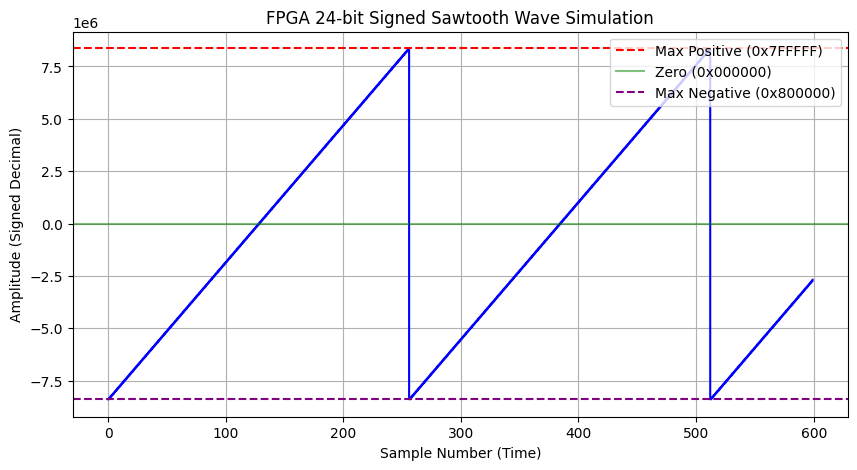

In [1]:
import matplotlib.pyplot as plt

# --- FPGA Parameters ---
SAW_START = 0x800000  # Start at the maximum negative binary value
SAW_STEP  = 0x010000  # The amount we add every sample

# --- 24-bit Math Limits ---
MAX_POS = 8388607     # 0x7FFFFF
MAX_NEG = -8388608    # 0x800000

# Helper function to mimic how the FPGA interprets 24-bit Two's Complement
def to_signed_24bit(val):
    # Keep only the bottom 24 bits (simulating a 24-bit hardware register)
    val = val & 0xFFFFFF 
    # If the 24th bit (sign bit) is 1, it's a negative number
    if val >= 0x800000:
        return val - 0x1000000
    return val

# --- Generate the Wave ---
y_values = []
current_val = SAW_START

# Let's simulate exactly 600 audio samples
for _ in range(600):
    # 1. Convert hardware binary to a signed integer for plotting
    y_values.append(to_signed_24bit(current_val))
    
    # 2. Add the step (The FPGA does this every sample request)
    current_val += SAW_STEP

# --- Plotting the Wave ---
plt.figure(figsize=(10, 5))
plt.plot(y_values, color='b', drawstyle='steps-post')

# Draw lines showing the 24-bit limits
plt.axhline(MAX_POS, color='r', linestyle='--', label="Max Positive (0x7FFFFF)")
plt.axhline(0, color='g', linestyle='-', alpha=0.5, label="Zero (0x000000)")
plt.axhline(MAX_NEG, color='purple', linestyle='--', label="Max Negative (0x800000)")

plt.title("FPGA 24-bit Signed Sawtooth Wave Simulation")
plt.xlabel("Sample Number (Time)")
plt.ylabel("Amplitude (Signed Decimal)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

## 4. Bonus: What Pitch (Frequency) is this wave?
You can figure out exactly what audio frequency this will play out of your RP2040 using simple math!

1. **How many steps to complete one wave?**
   Total size of a 24-bit register: $2^{24} = 16,777,216$
   Size of our step: `24'h010000` $= 65,536$
   $16,777,216 \div 65,536 = 256$ steps.
   *It takes exactly 256 samples to climb from the bottom to the top.*

2. **What is the frequency?**
   Our I2S sample rate ($f_S$) is $48,000 \text{ samples per second}$.
   If one wave takes 256 samples, then:
   $48,000 \div 256 = 187.5 \text{ waves per second}$

If you hook this up to a speaker, you will hear a **187.5 Hz** buzzing tone (a musical F#3)!  This is really how we figured out we needed to add `24'h010000` $= 65,536$ every sample at 48 kHz.

## 3. The SystemVerilog Code

Below is the complete implementation, split into three clear modules.

### Module 1: The Sawtooth Generator
This module does absolutely nothing regarding I2S timing. It just waits for the `sample_req` pulse and increments its output wave.

```systemverilog
// ============================================================================
// Module: sawtooth_gen
// Description: Generates a 24-bit sawtooth wave. Updates only when requested.
// ============================================================================
module sawtooth_gen #(
    parameter logic [23:0] SAW_START = 24'h800000,
    parameter logic [23:0] SAW_STEP  = 24'h010000
) (
    input  logic clk_30m,
    input  logic reset_n,
    input  logic sample_req,     // Handshake: Pulses high to ask for next value
    output logic [23:0] out_data // The 24-bit audio/SDR data
);

    always_ff @(posedge clk_30m or negedge reset_n) begin
        if (!reset_n) begin
            out_data <= SAW_START;
            
        end else if (sample_req == 1'b1) begin
            // Only step the wave forward when the I2S module asks for it!
            out_data <= out_data + SAW_STEP;
            
        end
    end

endmodule
```

### Module 2: The I2S Master Transmitter
This module translates our "Instruction Table" directly into code. Notice how decoupling the timing (the Metronome) from the logic makes it incredibly easy to read.

```systemverilog
// ============================================================================
// Module: i2s_master_tx
// Description: Standard Philips I2S Master. Reads parallel data and 
//              serializes it with correct BCK, WS, and 1-bit delay timing.
// ============================================================================
module i2s_master_tx #(
    parameter integer BCK_HALF_DIV = 5
) (
    input  logic clk_30m,
    input  logic reset_n,
    
    // Application Data Interface
    input  logic [23:0] left_data,   // Data for the Left channel
    input  logic [23:0] right_data,  // Data for the Right channel
    output logic sample_req,         // Handshake: Pulses high when frame ends
    
    // I2S Hardware Pins
    output logic i2s_bck,
    output logic i2s_ws,
    output logic i2s_tx_data
);

    // 1. The Metronome
    logic [2:0] bck_divider; // We need three bits to count to 5.
    
    // 2. The Tracker
    logic [5:0] bit_cnt;     // We need 6 bits to count to 64.

    always_ff @(posedge clk_30m or negedge reset_n) begin
        if (!reset_n) begin  // Reset everything to 0.
            bck_divider <= '0;
            bit_cnt     <= '0;
            i2s_bck     <= 1'b0;
            i2s_ws      <= 1'b0;
            i2s_tx_data <= 1'b0;
            sample_req  <= 1'b0;
            
        end else begin
            // Default state for our handshake pulse. It automatically
            // drops back to 0 unless explicitly set to 1 below.
            sample_req <= 1'b0;

            // --- THE METRONOME ---
            if (bck_divider == BCK_HALF_DIV - 1) begin
                bck_divider <= '0;
                i2s_bck     <= ~i2s_bck; // Toggle the Bit Clock

                // --- ACTION ON THE FALLING EDGE OF BCK ---
                // I2S spec says master MUST change data/WS on the falling edge.
                if (i2s_bck == 1'b1) begin
                    
                    // --- THE TRACKER ---
                    if (bit_cnt == 6'd63) begin
                        bit_cnt    <= 6'd0;
                        sample_req <= 1'b1; // Ask external module for new data!
                    end else begin
                        bit_cnt    <= bit_cnt + 1'b1;
                    end

                    // --- THE INSTRUCTION TABLE: WS ---
                    if (bit_cnt >= 6'd0 && bit_cnt <= 6'd31) begin
                        i2s_ws <= 1'b0; // Left Channel
                    end else begin
                        i2s_ws <= 1'b1; // Right Channel
                    end

                    // --- THE INSTRUCTION TABLE: DATA ---
                    if (bit_cnt == 6'd0 || bit_cnt == 6'd32) begin
                        i2s_tx_data <= 1'b0; // 1-bit delay padding
                        
                    end else if (bit_cnt >= 6'd1 && bit_cnt <= 6'd24) begin
                        i2s_tx_data <= left_data[24 - bit_cnt]; // Shift Left Data
                        
                    end else if (bit_cnt >= 6'd33 && bit_cnt <= 6'd56) begin
                        i2s_tx_data <= right_data[56 - bit_cnt]; // Shift Right Data
                        
                    end else begin
                        i2s_tx_data <= 1'b0; // Bottom 8 bits padding
                    end

                end
            end else begin
                bck_divider <= bck_divider + 1'b1;
            end
        end
    end

endmodule
```

### Module 3: The Top-Level Wrapper (The "Breadboard")
Finally, we need a module that wires the Sawtooth Generator's outputs to the I2S Driver's inputs. 

```systemverilog
// ============================================================================
// Module: top_i2s_demo
// Description: Top-level module wiring the Sawtooth generator to the I2S driver.
// ============================================================================
module top_i2s_demo (
    input  logic clk_30m,
    input  logic reset_n,
    
    // I2S Hardware Pins going to the RP2040
    output logic i2s_bck,
    output logic i2s_ws,
    output logic i2s_tx_data
);

    // Wires (logic signals) to connect the two modules together
    logic [23:0] audio_signal;
    logic        get_next_sample;

    // Instantiate Module 1: The Generator
    sawtooth_gen #(
        .SAW_START(24'h800000),
        .SAW_STEP(24'h010000)
    ) my_sawtooth (
        .clk_30m(clk_30m),
        .reset_n(reset_n),
        .sample_req(get_next_sample), // Input from I2S
        .out_data(audio_signal)       // Output to I2S
    );

    // Instantiate Module 2: The I2S Transmitter
    i2s_master_tx #(
        .BCK_HALF_DIV(5)
    ) my_i2s (
        .clk_30m(clk_30m),
        .reset_n(reset_n),
        .left_data(audio_signal),     // Play sawtooth on Left channel
        .right_data(audio_signal),    // Play sawtooth on Right channel
        .sample_req(get_next_sample), // Output asking for new data
        .i2s_bck(i2s_bck),
        .i2s_ws(i2s_ws),
        .i2s_tx_data(i2s_tx_data)
    );

endmodule
```

### How the Handshake Works
Look closely at the `get_next_sample` wire (driven by `sample_req`). 
When the I2S tracker hits `bit_cnt == 63`, it pulses this wire high. Because both modules share the same `clk_30m` clock, the Sawtooth module sees the high pulse on the very next system clock cycle and instantly updates its `out_data`. 

By the time the I2S module actually needs to shift the MSB out at `bit_cnt == 1` (several System Clock cycles later), the new audio data has been sitting securely on the `audio_signal` wire, ready to be read. This is exactly how complex digital subsystems safely synchronize and pass data to one another!